In [ ]:
!pip install -q sentence-transformers optuna xgboost scikit-learn pandas numpy imbalanced-learn seaborn nltk
import sys
import os
import random
import re
import joblib
import warnings
import pandas as pd
import numpy as np
import torch
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from scipy import sparse
from sentence_transformers import SentenceTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except:
        pass

seed_everything(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device.upper()}")

sent_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 30.4 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Device: CUDA


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#BƯỚC 2: Load Data & Advanced Labeling

loại bỏ duplicate, Chuyển đổi các cột giá tiền, rating từ dạng chuỗi (String) sang số (Float).Hàm clean_currency: Dùng Regex (biểu thức chính quy) để xóa ký tự ₹ hay dấu phẩy.

In [ ]:
try:
    df = pd.read_csv('amazon_products.csv')
    df.drop_duplicates(inplace=True)
except:
    df = pd.DataFrame({
        'title': ['Iphone 13 Pro']*200 + ['Samsung TV 4K']*200 + ['Nike Air Max']*200,
        'discounted_price': ['₹50,000']*600,
        'listed_price': ['₹60,000']*600,
        'rating': ['4.5']*600,
        'number_of_reviews': ['100']*600
    })

column_mapping = {
    'title': 'product_name', 'main_category': 'category',
    'discount_price': 'discounted_price', 'current/discounted_price': 'discounted_price',
    'ratings': 'rating', 'no_of_ratings': 'rating_count', 'number_of_reviews': 'rating_count',
    'listed_price': 'actual_price'
}
df.rename(columns=column_mapping, inplace=True)

def clean_currency(x):
    if isinstance(x, str):
        x = re.sub(r'[^\d.]', '', x)
        try: return float(x)
        except: return np.nan
    return x

if 'discounted_price' in df.columns: df['price_clean'] = df['discounted_price'].apply(clean_currency)
if 'actual_price' in df.columns: df['actual_price_clean'] = df['actual_price'].apply(clean_currency)
if 'rating' in df.columns: df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')

if 'rating_count' in df.columns:
    df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '')
    df['reviews_clean'] = pd.to_numeric(df['rating_count'], errors='coerce')

Label propagation / pseudo-label: chọn những mẫu có label_confidence >= 0.6 làm training set để train nhanh LogisticRegression trên prod_embeddings, sau đó predict nhãn cho những mẫu còn lại và update nhãn nếu model dự đoán với probability cao (>=0.45). Gắn nguồn nhãn là 'Propagated' cho những mẫu này.



In [ ]:
import re, joblib, numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.outliers_influence import variance_inflation_factor
#Làm sạch tên sản phẩm: chuyển về chữ thường, xóa ký tự đặc biệt.
def clean_text_for_keyword(text):
    if not isinstance(text, str): return ""
    t = text.lower()
    t = re.sub(r'[^\w\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

#So khớp từ khóa linh hoạt: Để bắt được cả số nhiều (s/es) hoặc các từ viết dính nhau/cách nhau
def flexible_kw_match(title_clean, kw):
    kw = kw.lower()
    if ' ' not in kw:
        pattern = r'\b' + re.escape(kw) + r'(s|es)?\b'
        if re.search(pattern, title_clean): return True
    escaped_kw = re.escape(kw)
    flex_pattern = escaped_kw.replace(r'\ ', r'[\s\-\_]*').replace(' ', r'[\s\-\_]*')
    try:
        if re.search(flex_pattern, title_clean): return True
    except: pass
    if kw.replace(' ', '') in title_clean.replace(' ', ''): return True
    return False

def trap_word_filter(text):
    text = text.lower()
    traps = ['protection plan', 'warranty', 'case for', 'cover for', 'adapter for', 'manual', 'guide', 'label', 'sticker']
    for word in traps:
        if word in text: return True
    return False

def fix_rating(x):
    if pd.isna(x): return np.nan
    match = re.search(r'(\d+(\.\d+)?)', str(x))
    if match:
        try:
            val = float(match.group(1))
            return val if 0 <= val <= 5 else np.nan
        except: return np.nan
    return np.nan

def clean_bought_count(x):
    if not isinstance(x, str): return 0
    match = re.search(r'(\d+)[+kK]*', x)
    if match:
        num = int(match.group(1))
        if 'k' in x.lower(): num *= 1000
        return num
    return 0

AMBIGUOUS = {'gaming', 'smart', 'pro', 'ultra', 'max', 'case', 'cover', 'wireless'}

#(Expert Keywords)
category_keywords = {
    'Laptops': ['laptop','notebook','macbook','chromebook','ultrabook','thinkpad','ideapad','surface','zenbook'],
    'Phones': ['iphone','smartphone','phone','cellphone','mobile','galaxy','pixel','redmi','realme'],
    'Headphones & Audio': ['headphone','earphone','earbud','airpod','buds','speaker','audio','soundbar','mic','amplifier'],
    'Cameras': ['camera','dslr','lens','webcam','gopro','drone','instax','camcorder'],
    'TV & Display': ['monitor','display','tv','television','projector','screen','oled','lcd'],
    'Computers & Accessories': ['desktop','pc','ssd','hdd','drive','usb','mouse','keyboard','router','wifi','printer','ink','ram','gpu','vga','motherboard','cpu','case','hub','dock'],
    'Chargers & Batteries': ['charger', 'cable', 'adapter', 'power bank', 'battery', 'charging', 'wire'],
    'Wearables': ['watch', 'smartwatch', 'fitbit', 'band', 'tracker', 'wearable'],
    'Gaming': ['console', 'playstation', 'ps5', 'ps4', 'xbox', 'nintendo', 'switch', 'joystick', 'controller', 'game'],
    'Smart Home': ['alexa', 'echo', 'smart', 'homekit', 'sensor', 'bulb']
}

# Giúp giảm số lượng nhãn, làm mô hình tập trung hơn và chính xác hơn.
KEYWORD_TO_MAIN_MAP = {
    'Laptops':'Laptops','Phones':'Phones','Headphones & Audio':'Audio','Cameras':'Cameras',
    'TV & Display':'TV & Display','Computers & Accessories':'Computers & Accessories',
    'Chargers & Batteries':'Other Electronics','Wearables':'Wearables','Gaming':'Gaming','Smart Home':'Other Electronics'
}

#ai o sánh tên sản phẩm với từng chữ trong danh sách này để xem cái nào giống nhất.
CANDIDATE_LABELS = [
    'Smartphone','Mobile Phone','Laptop','Gaming Laptop','Notebook','Camera','Digital Camera','DSLR',
    'Headphones','Earbuds','Speaker','Audio System','Television','Smart TV','Computer Monitor',
    'Computer Components','Hard Drive','Keyboard','Mouse','Printer','Networking Gear','Smartwatch','Fitness Tracker',
    'Video Game Console','Gaming Controller','Clothing','Shoes','Bag','Fashion Accessories','Home Decor','Furniture',
    'Kitchen Appliance','Bedding','Skincare','Makeup','Haircare','Supplements','Office Supplies','Stationery',
    'Toys','Board Games','Car Accessories','Automotive Parts','Sports Equipment','Exercise Gear',
    'Optics & Binoculars', 'Maintenance Plan', 'Paper Labels'
]

# đưa kết quả của AI về đúng định dạng.
CATEGORY_MAP_AI = {
    'Smartphone':'Phones','Mobile Phone':'Phones','Laptop':'Laptops','Gaming Laptop':'Laptops','Notebook':'Laptops',
    'Camera':'Cameras','Digital Camera':'Cameras','DSLR':'Cameras',
    'Headphones':'Audio','Earbuds':'Audio','Speaker':'Audio','Audio System':'Audio',
    'Television':'TV & Display','Smart TV':'TV & Display','Computer Monitor':'TV & Display',
    'Computer Components':'Computers & Accessories','Hard Drive':'Computers & Accessories',
    'Keyboard':'Computers & Accessories','Mouse':'Computers & Accessories','Printer':'Computers & Accessories',
    'Networking Gear':'Computers & Accessories','Smartwatch':'Wearables','Fitness Tracker':'Wearables',
    'Video Game Console':'Gaming','Gaming Controller':'Gaming','Clothing':'Fashion','Shoes':'Fashion',
    'Bag':'Fashion','Fashion Accessories':'Fashion','Home Decor':'Home & Kitchen','Furniture':'Home & Kitchen',
    'Kitchen Appliance':'Home & Kitchen','Bedding':'Home & Kitchen','Skincare':'Beauty','Makeup':'Beauty',
    'Haircare':'Beauty','Supplements':'Beauty','Office Supplies':'Office Products','Stationery':'Office Products',
    'Toys':'Toys & Games','Board Games':'Toys & Games','Car Accessories':'Automotive','Automotive Parts':'Automotive',
    'Sports Equipment':'Sports & Outdoors', 'Exercise Gear':'Sports & Outdoors',
    'Optics & Binoculars':'Other Electronics', 'Maintenance Plan':'Other Category', 'Paper Labels':'Other Category'
}

# BƯỚC 1: Gán nhãn bằng từ khóa
df['title_clean_for_kw'] = df['product_name'].fillna('').apply(clean_text_for_keyword)
kw_cat, kw_conf = [], []

for t in df['title_clean_for_kw']:
    found, found_kw, current_kws = None, None, []
    for cat, kws in category_keywords.items():
        for kw in kws:
            if flexible_kw_match(t, kw):
                found, found_kw, current_kws = cat, kw, kws
                break
        if found: break
    if found and found_kw in AMBIGUOUS:
        if not any(flexible_kw_match(t, sub) for sub in current_kws if sub != found_kw): found = None
    if found:
        kw_cat.append(found); kw_conf.append(0.75 if found_kw not in AMBIGUOUS else 0.6)
    else:
        kw_cat.append(None); kw_conf.append(0.0)

# BƯỚC 2: Gán nhãn bằng AI
products = df['product_name'].fillna('').astype(str).tolist()
prod_embeddings = sent_model.encode(products, batch_size=64, show_progress_bar=True)
label_embeddings = sent_model.encode(CANDIDATE_LABELS)

# Tính độ tương đồng Cosine (Cosine Similarity) giữa tên sản phẩm và các nhãn mục tiêu
similarity_scores = cosine_similarity(prod_embeddings, label_embeddings)
max_scores = np.max(similarity_scores, axis=1)
mapped_labels_ai = np.array([CATEGORY_MAP_AI.get(CANDIDATE_LABELS[i], CANDIDATE_LABELS[i]) for i in np.argmax(similarity_scores, axis=1)])

# BƯỚC 3: Kết hợp
final_cats, final_confs, sources = [], [], []
alpha, beta = 0.6, 0.4

for i in range(len(df)):
    kw, kw_c, ai, ai_score = kw_cat[i], kw_conf[i], mapped_labels_ai[i], float(max_scores[i])
    kw_main = KEYWORD_TO_MAIN_MAP.get(kw, kw) if kw else None
    if kw is not None and kw_main == ai:
        label, conf, source = ai, min(1.0, ai_score + 0.25), 'Keyword+AI'
        # Nếu khác nhau, tính điểm tổng hợp weighted average
    elif kw is not None:
        combined = alpha * kw_c + beta * ai_score
        if combined >= 0.75: label, conf, source = ai, combined, 'Ensemble'
        elif ai_score >= 0.82: label, conf, source = ai, ai_score, 'AI_strong'
        else: label, conf, source = kw_main, kw_c, 'Keyword'
    else:
        label, conf, source = ai, ai_score, 'Semantic_AI'
    final_cats.append(label); final_confs.append(conf); sources.append(source)

df['temp_label'], df['label_confidence'], df['label_source'] = final_cats, final_confs, sources

def price_sanity_check(row):
    cat, price, name = row['temp_label'], row['price_clean'], str(row['product_name']).lower()
    if trap_word_filter(name): return 'Other Electronics' if price > 20 else 'Other Category'
    if cat == 'Laptops' and price < 80: return 'Other Electronics'
    if cat == 'Phones' and price < 30: return 'Other Electronics'
    if cat == 'Cameras' and price < 25: return 'Other Electronics'
    return cat

df['temp_label'] = df.apply(price_sanity_check, axis=1)

# lan truyen nhan
CONFIDENCE_THRESHOLD = 0.6
train_mask = df['label_confidence'] >= CONFIDENCE_THRESHOLD
if train_mask.sum() > 100:
    X_prop, y_prop = prod_embeddings[train_mask], df.loc[train_mask, 'temp_label'].values
    label_classifier = LogisticRegression(n_jobs=-1, random_state=42, max_iter=1000, class_weight='balanced').fit(X_prop, y_prop)
    max_probs = np.max(label_classifier.predict_proba(prod_embeddings), axis=1)
    update_mask = ~train_mask
    confident_prop_mask = update_mask & (max_probs >= 0.45)
    df.loc[confident_prop_mask, 'temp_label'] = label_classifier.predict(prod_embeddings)[confident_prop_mask]
    df.loc[confident_prop_mask, 'label_source'] = 'Propagated'
    df.loc[update_mask & (max_probs < 0.45), 'temp_label'] = 'Unknown'

MIN_SAMPLES = 100
counts = df['temp_label'].value_counts()
valid_cats = counts[counts >= MIN_SAMPLES].index.tolist()
df['main_category_final'] = df['temp_label'].apply(lambda x: x if x in valid_cats and x != 'Unknown' else 'Other Category')

#NUMERIC FEATURE ENGINEERING
# Xử lý các cờ (flags) 0/1 cho Best Seller, Sponsored, Coupon
df['rating_clean'] = df['rating'].apply(fix_rating) if 'rating' in df.columns else np.nan
df['bought_count'] = df['bought_in_last_month'].apply(clean_bought_count) if 'bought_in_last_month' in df.columns else 0
df['is_best_seller_flag'] = df['is_best_seller'].apply(lambda x: 0 if str(x) == 'No Badge' or pd.isna(x) else 1)
df['is_sponsored_flag'] = df['is_sponsored'].apply(lambda x: 0 if str(x) == 'Organic' or pd.isna(x) else 1)
df['has_coupon'] = df['is_couponed'].apply(lambda x: 0 if str(x) == 'No Coupon' or pd.isna(x) else 1)

if 'price_clean' in df.columns and 'actual_price_clean' in df.columns:
    df['price_clean_was_missing'] = df['price_clean'].isna().astype(int)
    df['actual_price_clean_was_missing'] = df['actual_price_clean'].isna().astype(int)
    df['actual_price_clean'] = df['actual_price_clean'].fillna(df['price_clean'])
    df['price_clean'] = df['price_clean'].fillna(df['actual_price_clean'])


    df['actual_price_clean'] = np.maximum(df['actual_price_clean'], df['price_clean'])

# Điền giá trị thiếu (Imputation) và biến đổi Logarithmic (giảm độ lệch dữ liệu)
num_cols = ['price_clean', 'actual_price_clean', 'rating_clean', 'reviews_clean', 'bought_count']
for col in num_cols:
    if col in df.columns:
        if f'{col}_was_missing' not in df.columns:
            df[f'{col}_was_missing'] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].median())
        df[f'{col}_log'] = np.log1p(df[col])
        # Loại bỏ Outliers (cắt bỏ 1% đầu và 1% cuối)
        lower, upper = df[f'{col}_log'].quantile([0.01, 0.99])
        if upper > lower:
            df[f'{col}_log'] = np.clip(df[f'{col}_log'], lower, upper)

df['discount_pct'] = (df['actual_price_clean'] - df['price_clean']) / df['actual_price_clean']
df['discount_pct'] = df['discount_pct'].fillna(0).clip(0, 1)

numeric_log_cols = [f'{c}_log' for c in num_cols if f'{c}_log' in df.columns]
flag_cols = ['is_best_seller_flag', 'is_sponsored_flag', 'has_coupon']
missing_flags = [f'{c}_was_missing' for c in num_cols if f'{c}_was_missing' in df.columns]

all_features = numeric_log_cols + ['discount_pct'] + flag_cols + missing_flags

X_numeric_raw = df[all_features].replace([np.inf, -np.inf], np.nan).fillna(0)
constant_cols = [c for c in X_numeric_raw.columns if X_numeric_raw[c].nunique() <= 1]
X_vif_df = X_numeric_raw.drop(columns=constant_cols)

while True:
    vif_data = [variance_inflation_factor(X_vif_df.values, i) for i in range(X_vif_df.shape[1])]
    vif_s = pd.Series(vif_data, index=X_vif_df.columns)
    if vif_s.max() < 10: break
    X_vif_df = X_vif_df.drop(columns=[vif_s.idxmax()])

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(X_vif_df)
# Gộp (Stack) dữ liệu số và Vector văn bản (Embeddings) thành ma trận X cuối cùng
X_dense_all = np.hstack([numeric_scaled, prod_embeddings])

le = LabelEncoder()
df['label'] = le.fit_transform(df['main_category_final'])
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler_num.pkl')

print("VIF Features:", X_vif_df.columns.tolist())
print("\nFinal Labels:\n", df['main_category_final'].value_counts())

Batches:   0%|          | 0/667 [00:00<?, ?it/s]

VIF Features: ['price_clean_log', 'bought_count_log', 'discount_pct', 'is_best_seller_flag', 'is_sponsored_flag', 'has_coupon', 'price_clean_was_missing', 'actual_price_clean_was_missing', 'reviews_clean_was_missing']

Final Labels:
 main_category_final
Computers & Accessories    10300
Other Electronics           8337
Other Category              5452
Audio                       4732
Phones                      4337
TV & Display                3022
Cameras                     2892
Laptops                     2435
Gaming                       641
Wearables                    527
Name: count, dtype: int64


In [ ]:
print(" Kiểm tra nhanh 20 mẫu từ nguồn lan truyền:" )
check_df = df[df['label_source'] == 'Propagated'][['product_name', 'main_category_final', 'label_confidence']].sample(20)
display(check_df)

 Kiểm tra nhanh 20 mẫu từ nguồn lan truyền:


,product_name,main_category_final,label_confidence
3046,Godox V1 Pro C V1Pro-C USA Version Flash for C...,Cameras,0.518753
37013,Mounting Dream Sliding TV Wall Mount for 42-86...,TV & Display,0.582960
24791,ASURION 2 Year Outdoor Furniture Protection Pl...,Other Category,0.377657
4831,HP 12CP Financial Calculator,Computers & Accessories,0.237459
12812,"Google Coral USB Accelerator: ML Accelerator, ...",Computers & Accessories,0.469648
31257,ASURION 4 Year Kitchen Protection Plan ($60 - ...,Other Category,0.405109
40825,Sprayground PACMAN GHOST GANG SHARMOUTH,Other Electronics,0.214308
7001,ASURION 3 Year Lawn & Garden Extended Protecti...,Other Category,0.336303
10095,Apple iPhone 14 Plus Silicone Case with MagSaf...,Phones,0.506404
33261,"Energizer MAX AA Batteries (16 Pack), Double A...",Other Electronics,0.212215


CHECK

In [ ]:
final_columns = [
    'label', 'main_category_final', 'product_name',
    'price_clean', 'price_clean_log',
    'actual_price_clean', 'actual_price_clean_log',
    'rating_clean', 'rating_clean_log',
    'reviews_clean', 'reviews_clean_log',
    'bought_count', 'bought_count_log',
    'is_best_seller_flag', 'is_sponsored_flag', 'has_coupon',
    'price_clean_was_missing', 'rating_clean_was_missing', 'reviews_clean_was_missing',
    'label_source', 'label_confidence'
]

cols_to_keep = [c for c in final_columns if c in df.columns]
df_final = df[cols_to_keep].copy()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(f"Kích thước dữ liệu: {df_final.shape}")
print("-" * 85)

print("\n1. Mẫu dữ liệu ngẫu nhiên (Kiểm tra Nhãn & Nguồn):")
display(df_final.sample(min(10, len(df_final))))
print("-" * 85)

print("\n2. Phân bố nguồn gán nhãn (Source Distribution):")
source_stats = pd.DataFrame({
    'Counts': df_final['label_source'].value_counts(),
    'Percentage (%)': (df_final['label_source'].value_counts(normalize=True) * 100).round(2)
})
display(source_stats)

print("\n3. Phân bố nhãn mục tiêu (Target Categories):")
display(df_final['main_category_final'].value_counts())

print("\n4. Thống kê độ tin cậy (Label Confidence Stats):")
display(df_final['label_confidence'].describe())
print("-" * 85)

print("\n5. Kiểm tra Missing Values (NaN):")
missing_info = pd.DataFrame({
    'Dtype': df_final.dtypes,
    'Missing': df_final.isna().sum(),
    'Missing (%)': (df_final.isna().sum() / len(df_final) * 100).round(2)
})
display(missing_info)

critical_nans = df_final.isna().sum()[df_final.isna().sum() > 0]
if not critical_nans.empty:
    print("\nCác cột sau vẫn còn NaN:")
    print(critical_nans)
else:
    print("\nDữ liệu không còn NaN ở các cột chính.")
print("-" * 85)

print("\n6. Kiểm tra các đặc trưng số (Phân phối sau Log/Clip):")
log_cols = [c for c in df.columns if '_log' in c]
if log_cols:
    display(df[log_cols].describe())
else:
    print(" Chưa tìm thấy các cột _log.")


Kích thước dữ liệu: (42675, 21)
-------------------------------------------------------------------------------------

1. Mẫu dữ liệu ngẫu nhiên (Kiểm tra Nhãn & Nguồn):


,label,main_category_final,product_name,price_clean,price_clean_log,actual_price_clean,actual_price_clean_log,rating_clean,rating_clean_log,reviews_clean,reviews_clean_log,bought_count,bought_count_log,is_best_seller_flag,is_sponsored_flag,has_coupon,price_clean_was_missing,rating_clean_was_missing,reviews_clean_was_missing,label_source,label_confidence
19805,6,Other Electronics,CISCO DESIGNED Business CBS220-24P-4G Smart Sw...,430.19,6.066549,451.99,6.115870,4.5,1.704748,88.0,4.488636,0,0.000000,0,0,0,0,0,0,Keyword,0.750000
17698,6,Other Electronics,Duracell Coppertop AA Batteries with Power Boo...,22.25,3.146305,25.49,3.276767,4.8,1.757858,27783.0,10.232216,200,5.303305,0,0,0,0,0,0,Keyword,0.750000
24770,2,Computers & Accessories,"UGREEN 20Gbps M.2 NVMe SATA SSD Enclosure, 8TB...",24.98,3.257327,34.99,3.583241,4.1,1.629241,134.0,4.905275,200,5.303305,1,0,0,0,0,0,Propagated,0.547116
23026,6,Other Electronics,VIVO Magnetic 13 to 34 inch Monitor Mount for ...,39.99,3.713328,39.99,3.713328,4.9,1.774952,26.0,3.295837,100,4.615121,0,0,0,0,0,0,Keyword,0.750000
18919,5,Other Category,Pacsafe Vibe 325 Anti Theft Crossbody Casual D...,129.94,4.874739,129.94,4.874739,4.5,1.704748,376.0,5.932245,100,4.615121,0,0,0,0,0,0,Semantic_AI,0.334476
14611,0,Audio,"Alpine S2-S65 - Next-Generation S-Series 6.5"" ...",149.95,5.016949,149.95,5.016949,4.6,1.722767,97.0,4.584967,100,4.615121,1,0,0,0,0,0,Keyword+AI,0.677531
2541,0,Audio,Marshall Emberton III Portable Bluetooth Speak...,179.99,5.198442,179.99,5.198442,4.7,1.740466,379.0,5.940171,500,6.216606,0,0,0,0,0,0,Keyword+AI,0.678530
3565,2,Computers & Accessories,Canon CLI-281 XL Genuine BKCMY Four Color Valu...,72.95,4.303389,86.99,4.477223,4.7,1.740466,6885.0,8.837246,800,6.685861,0,0,0,0,0,0,Keyword+AI,0.640853
14222,2,Computers & Accessories,ASRock AMD B850 Steel Legend WiFi 7 Socket AM5...,77.00,4.356709,80.05,4.395066,4.4,1.686399,35.0,3.583519,50,3.931826,0,0,0,1,0,0,Keyword,0.750000
9531,2,Computers & Accessories,SanDisk Cruzer Glide 256GB USB 3.0 Flash Drive...,20.89,3.086030,27.07,3.334701,4.7,1.740466,1897.0,7.548556,300,5.707110,0,0,0,0,0,0,Keyword+AI,0.626643


-------------------------------------------------------------------------------------

2. Phân bố nguồn gán nhãn (Source Distribution):


,Counts,Percentage (%)
label_source,,
Keyword,18187,42.62
Keyword+AI,14489,33.95
Propagated,8272,19.38
Semantic_AI,1726,4.04
Ensemble,1,0.00



3. Phân bố nhãn mục tiêu (Target Categories):


...

,label_confidence
count,42675.000000
mean,0.653679
std,0.166920
min,0.107812
25%,0.606209
50%,0.750000
75%,0.750000
max,1.000000


-------------------------------------------------------------------------------------

5. Kiểm tra Missing Values (NaN):


,Dtype,Missing,Missing (%)
label,int64,0,0.0
main_category_final,object,0,0.0
product_name,object,0,0.0
price_clean,float64,0,0.0
price_clean_log,float64,0,0.0
actual_price_clean,float64,0,0.0
actual_price_clean_log,float64,0,0.0
rating_clean,float64,0,0.0
rating_clean_log,float64,0,0.0
reviews_clean,float64,0,0.0



Dữ liệu không còn NaN ở các cột chính.
-------------------------------------------------------------------------------------

6. Kiểm tra các đặc trưng số (Phân phối sau Log/Clip):


,price_clean_log,actual_price_clean_log,rating_clean_log,reviews_clean_log,bought_count_log
count,42675.000000,42675.000000,42675.000000,42675.000000,42675.000000
mean,4.398207,4.483225,1.685549,5.916905,4.071096
std,1.129114,1.110601,0.068487,2.175784,2.593956
min,2.115050,2.173615,1.435085,0.693147,0.000000
25%,3.664714,3.862390,1.648659,4.442651,3.931826
50%,4.356709,4.395066,1.704748,5.840642,4.615121
75%,4.875121,4.948689,1.722767,7.510157,5.707110
max,7.667603,7.714655,1.791759,10.508803,9.903538


## BƯỚC 3: Feature Engineering & Save Artifacts

X_dense_emb (PCA): Giảm từ 384 chiều xuống mức giữ 90% thông tin. Để tránh Curse of Dimensionality - khi có quá nhiều biến mà dữ liệu ít, mô hình sẽ bị Overfitting.

X_tfidf_reduced(TF-IDF + TruncatedSVD/LSA): TF-IDF lấy đặc trưng từ khóa, LSA giúp gom các từ đồng nghĩa lại.

*   social_proof (log of rating × reviews): mô tả độ tin cậy/độ phổ biến — thường correlates với doanh số & category. Dùng log để giảm skew.
*   word_count: tiêu đề dài hay ngắn có thể phản ánh loại sản phẩm (ví dụ linh kiện thường tên ngắn, sản phẩm thời trang tên có nhiều mô tả).

*   discount_pct: (Giá gốc - Giá giảm) / Giá gốc. Ý nghĩa: Sản phẩm giảm giá sâu thường dễ nhận diện ngành hàng hơn.
*   brand_tier: tách brand có ảnh hưởng lớn đến danh mục & giá.
*   price_log / reviews_log: log transform giúp phân phối gần chuẩn (reduce skew) — nhiều biến giá/review có phân bố dài phải (long-tail).

**tạo các feature dựa trên *tên, rating, reviews, price*; dùng log transform để giảm skew; dùng TF-IDF+SVD để chuyển text thành features số; dùng PCA để giảm chiều embedding, giữ 90% variance.**



In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib, numpy as np, pandas as pd, re
from statsmodels.stats.outliers_influence import variance_inflation_factor

stop_words = set(['the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'am', 'to', 'for', 'in', 'on', 'at', 'by', 'with', 'this', 'that', 'of', 'from', 'it', 'its', 'they', 'them', 'their', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'which', 'who', 'whom', 'whose', 'where', 'when', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves'])

top_brands_list = ['western digital', 'apple', 'samsung', 'dell', 'hp', 'lenovo', 'asus', 'acer', 'sony', 'logitech', 'jbl', 'bose', 'tp-link', 'sandisk', 'xiaomi', 'oppo', 'vivo', 'oneplus', 'google', 'amazon', 'nintendo', 'playstation', 'xbox', 'msi', 'gigabyte']
premium_brands = ['apple', 'samsung', 'sony', 'dell', 'hp', 'bose', 'playstation', 'xbox', 'nintendo']

def clean_text_pro(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\.]', ' ', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return " ".join(words)

def get_brand_tier(name):
    name_lower = str(name).lower()
    for brand in premium_brands:
        if re.search(r'\b' + re.escape(brand) + r'\b', name_lower): return 2
    for brand in top_brands_list:
        if re.search(r'\b' + re.escape(brand) + r'\b', name_lower): return 1
    return 0

df_train = df[(df['label_confidence'] >= 0.5) | (df['label_source'] == 'Keyword+AI')].copy().reset_index(drop=True)

df_train['price_log'] = np.log1p(df_train['price_clean'])
df_train['reviews_log'] = np.log1p(df_train['reviews_clean'])
df_train['bought_count_log'] = np.log1p(df_train['bought_count'])

df_train['full_text'] = df_train['product_name'].apply(clean_text_pro)
df_train['social_proof'] = np.log1p(df_train['rating_clean'] * df_train['reviews_clean'])
df_train['word_count'] = df_train['product_name'].str.split().str.len()
df_train['brand_tier'] = df_train['product_name'].apply(get_brand_tier)

pca = PCA(n_components=0.90, svd_solver='full', random_state=42)
emb_src = prod_embeddings[df_train.index] if 'prod_embeddings' in globals() else embeddings[df_train.index]
X_dense_emb = pca.fit_transform(emb_src)


# 2. TF-IDF + TruncatedSVD (LSA): Trích xuất đặc trưng từ khóa văn bản.
# TF-IDF: Đo tầm quan trọng của từ.
# TruncatedSVD: Nén ma trận TF-IDF khổng lồ thành 256 chiều mang ngữ nghĩa ẩn.
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=10)
X_sparse_tfidf = tfidf.fit_transform(df_train['full_text'])
svd_n = min(256, X_sparse_tfidf.shape[1] - 1)
svd = TruncatedSVD(n_components=svd_n, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_sparse_tfidf)

numeric_cols_input = ['price_log', 'rating_clean', 'reviews_log', 'bought_count_log', 'discount_pct', 'social_proof', 'word_count', 'brand_tier', 'is_best_seller_flag', 'has_coupon']
X_numeric = df_train[numeric_cols_input].fillna(0)
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(X_numeric)

X_vif_df = pd.DataFrame(numeric_scaled, columns=numeric_cols_input)
while True:
    vifs = [variance_inflation_factor(X_vif_df.values, i) for i in range(X_vif_df.shape[1])]
    max_vif = max(vifs)
    if max_vif <= 5.0: break
    drop_col = X_vif_df.columns[vifs.index(max_vif)]
    X_vif_df.drop(columns=[drop_col], inplace=True)
    numeric_cols_input.remove(drop_col)

# np.hstack: Ghép nối ngang tất cả đặc trưng (Số + PCA AI + SVD Văn bản)
X_dense_all = np.hstack([X_vif_df.values, X_dense_emb, X_tfidf_reduced])
y = df_train['label'].values

joblib.dump(scaler, 'scaler_pro.pkl')
joblib.dump(pca, 'pca_pro.pkl')
joblib.dump(tfidf, 'tfidf_pro.pkl')
joblib.dump(svd, 'svd_pro.pkl')
joblib.dump(X_vif_df.columns.tolist(), 'numeric_cols.pkl')

print(f"Features: {X_vif_df.columns.tolist()}")
print(f"Shape: {X_dense_all.shape}")
print(f"Classes: {len(np.unique(y))}")

Features: ['price_log', 'rating_clean', 'reviews_log', 'bought_count_log', 'discount_pct', 'word_count', 'brand_tier', 'is_best_seller_flag', 'has_coupon']
Shape: (34857, 372)
Classes: 10


##CHECK DỮ LIỆU

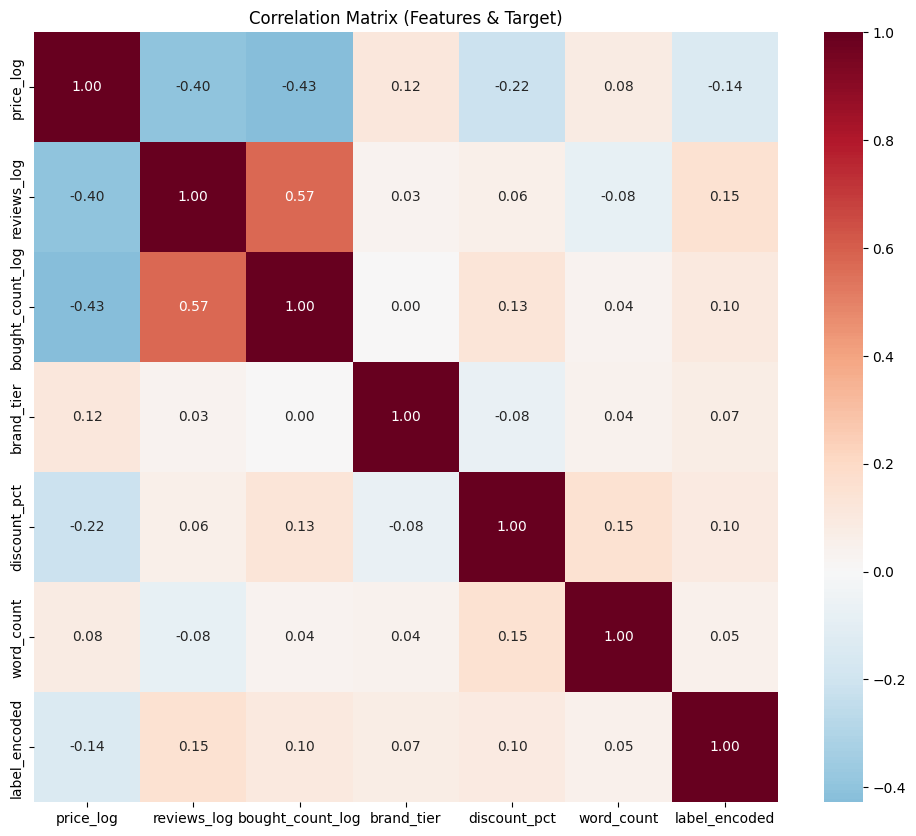

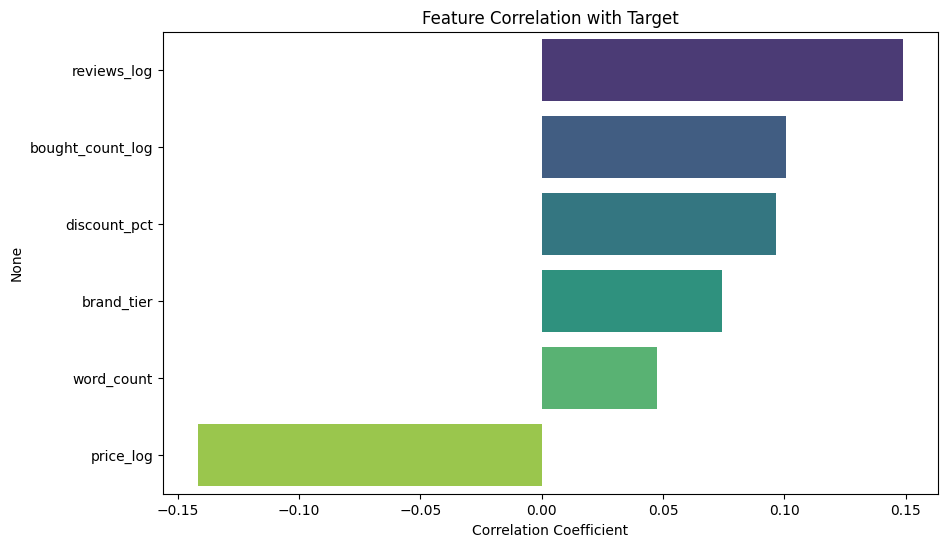

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder

cols_to_show = ['price_log', 'reviews_log', 'bought_count_log', 'brand_tier', 'discount_pct', 'word_count']

if 'label_encoded' not in df_train.columns:
    df_train['label_encoded'] = LabelEncoder().fit_transform(df_train['main_category_final'])

plt.figure(figsize=(12, 10))
sns.heatmap(df_train[cols_to_show + ['label_encoded']].corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation Matrix (Features & Target)")
plt.show()

plt.figure(figsize=(10, 6))
target_corr = df_train[cols_to_show + ['label_encoded']].corr()['label_encoded'].sort_values(ascending=False).drop('label_encoded')
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')
plt.title("Feature Correlation with Target")
plt.xlabel("Correlation Coefficient")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

base_columns = [
    'label', 'main_category_final', 'product_name',
    'price_clean', 'actual_price_clean', 'rating_clean', 'reviews_clean', 'bought_count',
    'is_best_seller_flag', 'has_coupon', 'label_source', 'label_confidence'
]

extra_cols = [
    'price_log', 'reviews_log', 'bought_count_log',
    'discount_pct', 'word_count', 'brand_tier'
]

final_columns = base_columns + extra_cols
cols_to_check = [c for c in final_columns if c in df_train.columns]
df_audit = df_train[cols_to_check].copy()

print("="*80)
print(f"1. Tổng quan bộ dữ liệu huấn luyện:")
print(f"   - Số lượng mẫu (Dòng): {df_audit.shape[0]:,}")
print(f"   - Số lượng đặc trưng (Cột): {df_audit.shape[1]}")
print(f"   - Độ tin cậy tối thiểu: {df_audit['label_confidence'].min():.2f}")
print("-" * 40)

print("2. Kiểm tra lỗi Logic & Chất lượng:")
errors = 0

neg_price = df_audit[df_audit['price_clean'] < 0]
if len(neg_price) > 0:
    print(f"  CẢNH BÁO: Có {len(neg_price)} dòng giá bị âm.")
    errors += 1
else:
    print("   Giá tiền: Hợp lệ (>= 0).")

weird_rating = df_audit[(df_audit['rating_clean'] < 1) | (df_audit['rating_clean'] > 5)]
if len(weird_rating) > 0:
    print(f"   CẢNH BÁO: Có {len(weird_rating)} dòng Rating nằm ngoài thang 1-5.")
    errors += 1
else:
    print("   Rating: Hợp lệ (1.0 - 5.0).")

nan_info = df_audit.isna().sum()
nan_cols = nan_info[nan_info > 0]
if not nan_cols.empty:
    print(f"   Còn sót NaN ở: {nan_cols.to_dict()}")
    errors += 1
else:
    print("   Dữ liệu: Hoàn toàn sạch (Không còn NaN).")

# Kiểm tra nhãn mục tiêu
if 'label' in df_audit.columns:
    n_labels = df_audit['label'].nunique()
    print(f"   Nhãn (Label): Sẵn sàng với {n_labels} nhóm phân loại.")
else:
    print("  LỖI NGHIÊM TRỌNG: Mất cột 'label'!")
    errors += 1


# ---  PHÂN PHỐI NHÃN (CLASS BALANCE) ---
print("-" * 40)
print("3. Phân phối nhãn mục tiêu (Class Distribution):")
dist = df_audit['main_category_final'].value_counts(normalize=True) * 100
for cat, pct in dist.items():
    print(f"   - {cat:<25}: {pct:>6.2f}% ({df_audit['main_category_final'].value_counts()[cat]:>5} mẫu)")

print("="*80)
if errors == 0:
    print(" KẾT LUẬN: DỮ LIỆU ĐÃ ĐẠT CHUẨN.")
else:
    print(f" KẾT LUẬN: CẦN XỬ LÝ {errors} VẤN ĐỀ.")
print("="*80)

print("\n4. Thống kê mô tả các biến số quan trọng:")
num_cols = df_audit.select_dtypes(include=[np.number]).columns.tolist()
display(df_audit[num_cols].describe().T.style.background_gradient(cmap='Greens'))

print("\n5. Soi 5 dòng dữ liệu thực tế (Random Sample):")
display(df_audit.sample(5))

1. Tổng quan bộ dữ liệu huấn luyện:
   - Số lượng mẫu (Dòng): 34,857
   - Số lượng đặc trưng (Cột): 18
   - Độ tin cậy tối thiểu: 0.38
----------------------------------------
2. Kiểm tra lỗi Logic & Chất lượng:
   Giá tiền: Hợp lệ (>= 0).
   Rating: Hợp lệ (1.0 - 5.0).
   Dữ liệu: Hoàn toàn sạch (Không còn NaN).
   Nhãn (Label): Sẵn sàng với 10 nhóm phân loại.
----------------------------------------
3. Phân phối nhãn mục tiêu (Class Distribution):
   - Computers & Accessories  :  25.02% ( 8721 mẫu)
   - Other Electronics        :  20.21% ( 7043 mẫu)
   - Audio                    :  13.15% ( 4582 mẫu)
   - Phones                   :  11.24% ( 3918 mẫu)
   - Cameras                  :   8.18% ( 2852 mẫu)
   - TV & Display             :   7.94% ( 2766 mẫu)
   - Laptops                  :   6.98% ( 2432 mẫu)
   - Other Category           :   3.99% ( 1392 mẫu)
   - Gaming                   :   1.82% (  633 mẫu)
   - Wearables                :   1.49% (  518 mẫu)
 KẾT LUẬN: DỮ LIỆU ĐÃ ĐẠT 

,count,mean,std,min,25%,50%,75%,max
label,34857.000000,3.883151,2.710355,0.000000,2.000000,4.000000,6.000000,9.000000
price_clean,34857.000000,195.046191,364.147397,2.970000,39.990000,77.000000,149.000000,4699.000000
actual_price_clean,34857.000000,211.772877,400.023192,3.590000,49.950000,80.050000,169.990000,5399.000000
rating_clean,34857.000000,4.388002,0.387410,1.000000,4.200000,4.500000,4.600000,5.000000
reviews_clean,34857.000000,2901.580486,12135.374908,1.000000,83.000000,343.000000,1886.000000,645418.000000
bought_count,34857.000000,857.779384,5686.844190,0.000000,50.000000,100.000000,300.000000,828000.000000
is_best_seller_flag,34857.000000,0.045529,0.208464,0.000000,0.000000,0.000000,0.000000,1.000000
has_coupon,34857.000000,0.055685,0.229315,0.000000,0.000000,0.000000,0.000000,1.000000
label_confidence,34857.000000,0.724967,0.068762,0.382967,0.703770,0.750000,0.750000,1.000000
price_log,34857.000000,4.483518,1.154249,1.378766,3.713328,4.356709,5.010635,8.455318



5. Soi 5 dòng dữ liệu thực tế (Random Sample):


,label,main_category_final,product_name,price_clean,actual_price_clean,rating_clean,reviews_clean,bought_count,is_best_seller_flag,has_coupon,label_source,label_confidence,price_log,reviews_log,bought_count_log,discount_pct,word_count,brand_tier
12794,8,TV & Display,"RCA 10.1"" WiFi Digital Picture Frame Uhale App...",59.99,79.99,3.5,6.0,0,0,0,Keyword,0.75000,4.110710,1.945910,0.000000,0.250031,29,0
27512,7,Phones,iOttie Velox Pro MagSafe Compatible Dash & Win...,79.95,79.95,4.0,1881.0,100,0,0,Keyword,0.75000,4.393832,7.540090,4.615121,0.000000,27,0
27501,2,Computers & Accessories,TRX Training 6 Month On-Demand Membership - Un...,49.95,49.95,4.7,8.0,0,0,0,Keyword,0.75000,3.930845,2.197225,0.000000,0.000000,21,0
32120,4,Laptops,Lenovo IdeaPad Slim 3 Laptop Computer for Home...,699.99,2899.00,4.8,14.0,50,0,0,Keyword+AI,0.80936,6.552494,2.708050,3.931826,0.758541,34,1
13098,6,Other Electronics,Motorola 56531 Multi Unit Charger / Cloning St...,199.99,199.99,4.3,105.0,50,0,0,Keyword,0.75000,5.303255,4.663439,3.931826,0.000000,8,0


## BƯỚC 4: Optuna with SQLite Storage & GPU + TRAIN

**Tạo ma trận đặc trưng X_train_all và label y_train, chia train/test, áp SMOTE, và encode labels.**

*   numeric_cols = [...] — chọn các cột numeric/log/flags dùng.
*   X_num = df_train[numeric_cols].fillna(0) → StandardScaler() → X_num_scaled.
*   X_emb = pca.transform(prod_embeddings[df_train.index]) — embeddings đã giảm bằng PCA.
*   X_text = svd.transform(X_sparse_tfidf) — LSA output.

*   X_train_all = np.hstack([X_num_scaled, X_emb, X_text])

**Biến tạo: X_train_all, X_train, X_test, y_train, y_test, X_num_scaled, X_emb, X_text.**


Stratify giữ tỉ lệ lớp giữa train & test.
SMOTE áp trên tập train (để tránh leakage).


[I 2025-12-20 06:03:38,606] A new study created in RDB with name: no-name-7df0117c-245e-4b87-baf5-fd62c43c4c09
[I 2025-12-20 06:35:02,815] Trial 0 finished with value: 0.9557435047383265 and parameters: {'learning_rate': 0.0249816047538945, 'num_leaves': 62, 'max_depth': 9, 'min_child_samples': 110, 'reg_alpha': 0.20513382630874505, 'reg_lambda': 0.2051110418843398, 'subsample': 0.7116167224336398, 'colsample_bytree': 0.7732352291549871}. Best is trial 0 with value: 0.9557435047383265.
[I 2025-12-20 07:01:32,996] Trial 1 finished with value: 0.9543477513986488 and parameters: {'learning_rate': 0.034044600469728355, 'num_leaves': 51, 'max_depth': 4, 'min_child_samples': 147, 'reg_alpha': 4.622589001020832, 'reg_lambda': 0.26587543983272705, 'subsample': 0.73636499344142, 'colsample_bytree': 0.6366809019706867}. Best is trial 0 with value: 0.9557435047383265.
[I 2025-12-20 07:31:28,526] Trial 2 finished with value: 0.9559826274635783 and parameters: {'learning_rate': 0.02216968971838151,

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[584]	valid_0's multi_logloss: 0.134684

Overall Accuracy:      95.93%
Balanced Accuracy:     95.17%
Macro F1-Score:        0.9562
--------------------------------------------------
                         precision    recall  f1-score   support

                  Audio       0.97      0.94      0.95       917
                Cameras       0.98      0.98      0.98       570
Computers & Accessories       0.95      0.97      0.96      1744
                 Gaming       0.95      0.97      0.96       127
                Laptops       0.97      0.97      0.97       486
         Other Category       0.97      0.89      0.93       278
      Other Electronics       0.96      0.96      0.96      1409
                 Phones       0.96      0.97      0.96       784
           TV & Display       0.95      0.93      0.94       553
              Wearables       0.96      0.93      0.95       104

    

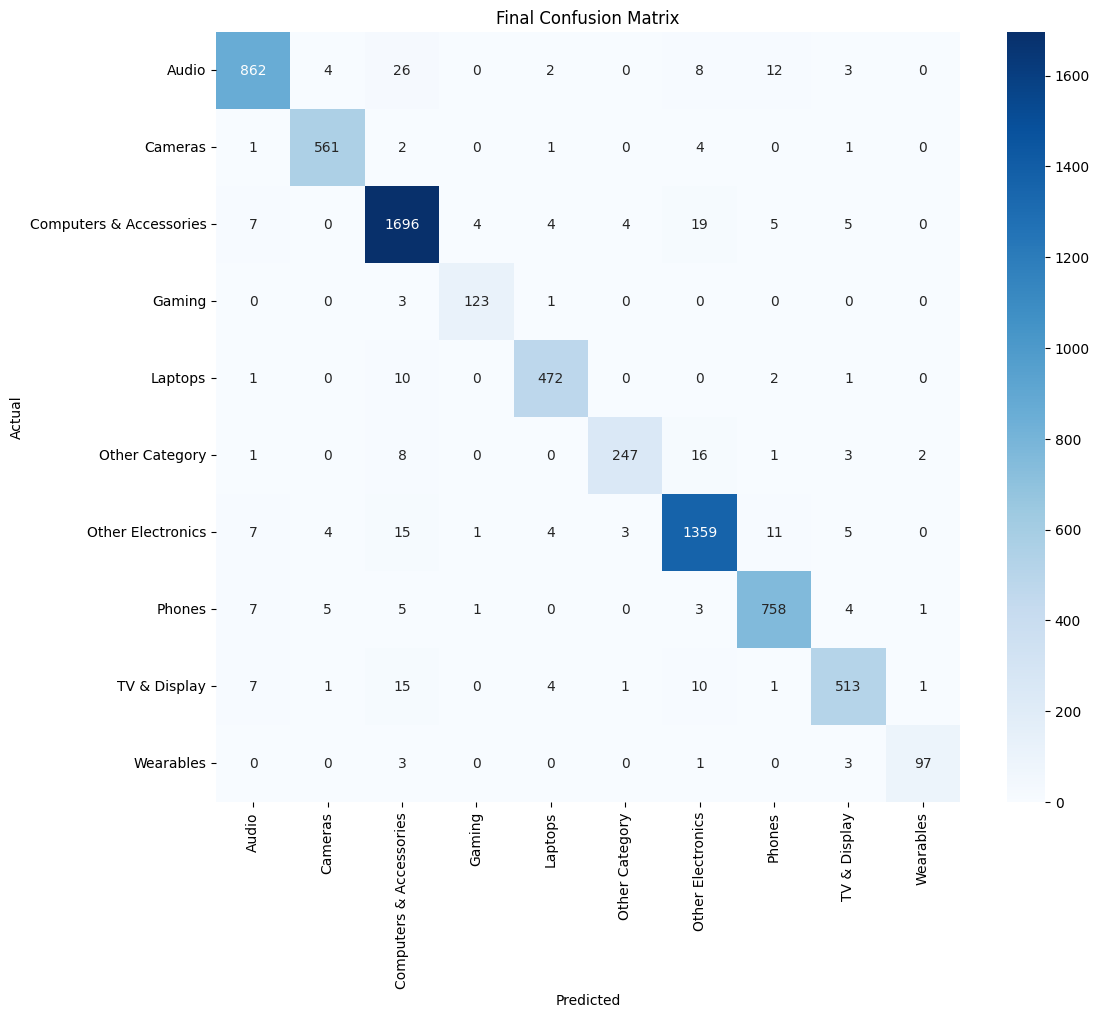

Đã đóng gói thành công: KetQua_DoAn_Amazon.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib, os, zipfile, numpy as np, pandas as pd, optuna, lightgbm as lgb, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sentence_transformers import SentenceTransformer
from optuna.samplers import TPESampler
from google.colab import files
24
def safe_joblib_load(filename):
    return joblib.load(filename) if os.path.exists(filename) else None

le = safe_joblib_load('label_encoder.pkl') or globals().get('le')
pca = safe_joblib_load('pca_pro.pkl')
svd = safe_joblib_load('svd_pro.pkl')
tfidf = safe_joblib_load('tfidf_pro.pkl')
scaler = safe_joblib_load('scaler_pro.pkl')
numeric_cols_final = safe_joblib_load('numeric_cols.pkl')

X_train_optuna, X_test, y_train_optuna, y_test = train_test_split(
    X_dense_all, y, test_size=0.2, stratify=y, random_state=42
)

USE_SMOTE_IN_CV = True
N_TRIALS = 50
TIMEOUT = 14400
DB_NAME = "sqlite:///optuna_amazon_pro.db"

def objective(trial):
    params = {
        'n_estimators': 10000,
        'objective': 'multiclass',
        'metric': 'multi_logloss', # Hàm mất mát để tối ưu
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'num_leaves': trial.suggest_int('num_leaves', 20, 64),
        'max_depth': trial.suggest_int('max_depth', 4, 10), # Độ sâu của cây
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 150),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),
    }

# StratifiedKFold (k=5): Chia tập Train làm 5 phần, luân phiên train trên 4 phần, test trên 1 phần còn lại.
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in kf.split(X_train_optuna, y_train_optuna):
        X_tr, X_val = X_train_optuna[train_idx], X_train_optuna[val_idx]
        y_tr, y_val = y_train_optuna[train_idx], y_train_optuna[val_idx]

        # SMOTE:
        if USE_SMOTE_IN_CV:
            smote = SMOTE(random_state=42)
            X_tr_final, y_tr_final = smote.fit_resample(X_tr, y_tr)
            sw = None
        else:
            X_tr_final, y_tr_final = X_tr, y_tr
            cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
            sw = np.array([dict(zip(np.unique(y_tr), cw))[c] for c in y_tr])

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr_final, y_tr_final,
            sample_weight=sw,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        f1_scores.append(f1_score(y_val, model.predict(X_val), average='macro'))

    return np.mean(f1_scores)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42), storage=DB_NAME, load_if_exists=True)
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT)

best_params = study.best_params
final_model = lgb.LGBMClassifier(**best_params, n_estimators=5000, random_state=42, n_jobs=-1, class_weight='balanced')

final_model.fit(
    X_train_optuna, y_train_optuna,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=150)]
)

y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print(f"Overall Accuracy:      {acc:.2%}")
print(f"Balanced Accuracy:     {bal_acc:.2%}")
print(f"Macro F1-Score:        {macro_f1:.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

model_path = 'amazon_classifier.pkl'
joblib.dump(final_model, model_path)

joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler_pro.pkl')
joblib.dump(pca, 'pca_pro.pkl')
joblib.dump(svd, 'svd_pro.pkl')
joblib.dump(tfidf, 'tfidf_pro.pkl')
joblib.dump(numeric_cols_final, 'numeric_cols.pkl')

files_to_zip = [
    model_path, 'label_encoder.pkl', 'pca_pro.pkl',
    'tfidf_pro.pkl', 'svd_pro.pkl', 'scaler_pro.pkl', 'numeric_cols.pkl'
]

zip_filename = 'KetQua_DoAn_Amazon.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for f in files_to_zip:
        if os.path.exists(f):
            zipf.write(f)

print(f"Đã đóng gói thành công: {zip_filename}")
files.download(zip_filename)

class ClassificationModel:
    def __init__(self, model_path='amazon_classifier.pkl'):
        self.model = joblib.load(model_path)
        self.le = joblib.load('label_encoder.pkl')
        self.pca = joblib.load('pca_pro.pkl')
        self.svd = joblib.load('svd_pro.pkl')
        self.tfidf = joblib.load('tfidf_pro.pkl')
        self.scaler = joblib.load('scaler_pro.pkl')
        self.numeric_cols = joblib.load('numeric_cols.pkl')
        self.sent_model = SentenceTransformer('all-MiniLM-L6-v2')

    def preprocess(self, name, price, rating, reviews_count, bought_count, actual_price):
        text = clean_text_pro(f"{name}")
        emb = self.pca.transform(self.sent_model.encode([text]))
        tfidf_vec = self.svd.transform(self.tfidf.transform([text]))
        scaler_input_cols = [
            'price_log', 'rating_clean', 'reviews_log', 'bought_count_log',
            'discount_pct', 'social_proof', 'word_count', 'brand_tier',
            'is_best_seller_flag', 'has_coupon'
        ]
        rev_val = float(reviews_count) if reviews_count and reviews_count > 0 else 1.0
        rat_val = float(rating) if rating and rating > 0 else 4.2
        feat = {
            'price_log': np.log1p(price),
            'rating_clean': float(rating) if rating else 4.2,
            'reviews_log': np.log1p(float(reviews_count)) if reviews_count else 0,
            'bought_count_log': np.log1p(bought_count),
            'discount_pct': (actual_price - price)/actual_price if actual_price > price else 0,
            'social_proof': np.log1p(float(rating)*float(reviews_count)) if rating and reviews_count else 0,
            'word_count': len(name.split()),
            'brand_tier': get_brand_tier(name),
            'is_best_seller_flag': 0,
            'has_coupon': 0
        }
        full_num_df = pd.DataFrame([[feat.get(c, 0) for c in scaler_input_cols]], columns=scaler_input_cols)
        scaled_full = pd.DataFrame(self.scaler.transform(full_num_df), columns=scaler_input_cols)
        final_num = scaled_full[self.numeric_cols].values
        return np.hstack([final_num, emb, tfidf_vec])

    def predict(self, name, price, rating=4.2, reviews_count=1, bought_count=0, actual_price=0):
        X_in = self.preprocess(name, price, rating, reviews_count, bought_count, actual_price)
        prob = self.model.predict_proba(X_in)
        idx = np.argmax(prob)
        return {"label": self.le.inverse_transform([idx])[0], "confidence": round(float(np.max(prob)), 4)}



In [ ]:
class ClassificationModel:
    def __init__(self, model_path='amazon_classifier.pkl'):
        self.model = joblib.load(model_path)
        self.le = joblib.load('label_encoder.pkl')
        self.pca = joblib.load('pca_pro.pkl')
        self.svd = joblib.load('svd_pro.pkl')
        self.tfidf = joblib.load('tfidf_pro.pkl')
        self.scaler = joblib.load('scaler_pro.pkl')
        self.numeric_cols = joblib.load('numeric_cols.pkl')
        self.sent_model = SentenceTransformer('all-MiniLM-L6-v2')

    def preprocess(self, name, price, rating, reviews_count, bought_count, actual_price):
        text = clean_text_pro(f"{name}")
        emb = self.pca.transform(self.sent_model.encode([text]))
        tfidf_vec = self.svd.transform(self.tfidf.transform([text]))
        scaler_input_cols = [
            'price_log', 'rating_clean', 'reviews_log', 'bought_count_log',
            'discount_pct', 'social_proof', 'word_count', 'brand_tier',
            'is_best_seller_flag', 'has_coupon'
        ]
        rev_val = float(reviews_count) if reviews_count and reviews_count > 0 else 1.0
        rat_val = float(rating) if rating and rating > 0 else 4.2
        feat = {
            'price_log': np.log1p(price),
            'rating_clean': float(rating) if rating else 4.2,
            'reviews_log': np.log1p(float(reviews_count)) if reviews_count else 0,
            'bought_count_log': np.log1p(bought_count),
            'discount_pct': (actual_price - price)/actual_price if actual_price > price else 0,
            'social_proof': np.log1p(float(rating)*float(reviews_count)) if rating and reviews_count else 0,
            'word_count': len(name.split()),
            'brand_tier': get_brand_tier(name),
            'is_best_seller_flag': 0,
            'has_coupon': 0
        }
        full_num_df = pd.DataFrame([[feat.get(c, 0) for c in scaler_input_cols]], columns=scaler_input_cols)
        scaled_full = pd.DataFrame(self.scaler.transform(full_num_df), columns=scaler_input_cols)
        final_num = scaled_full[self.numeric_cols].values
        return np.hstack([final_num, emb, tfidf_vec])

    def predict(self, name, price, rating=4.2, reviews_count=1, bought_count=0, actual_price=0):
        X_in = self.preprocess(name, price, rating, reviews_count, bought_count, actual_price)
        prob = self.model.predict_proba(X_in)
        idx = np.argmax(prob)
        return {"label": self.le.inverse_transform([idx])[0], "confidence": round(float(np.max(prob)), 4)}



In [ ]:
import joblib
import pandas as pd
import numpy as np

engine = ClassificationModel()

test_cases = [
    {"name": "Apple iPhone 15 Pro Max 256GB Titanium", "price": 1199, "actual": 1299, "rating": 4.8, "reviews": 5000},
    {"name": "Samsung 32-inch Odyssey G5 Gaming Monitor", "price": 300, "actual": 350, "rating": 4.5, "reviews": 1200},
    {"name": "Logitech MX Master 3S Wireless Mouse", "price": 99, "actual": 99, "rating": 4.9, "reviews": 3000},
    {"name": "Leather Case for iPhone 15", "price": 25, "actual": 45, "rating": 4.2, "reviews": 800},
    {"name": "Premium Yoga Mat for Exercise", "price": 20, "actual": 30, "rating": 4.0, "reviews": 150},
    {"name": "PlayStation 5 Console (PS5)", "price": 499, "actual": 499, "rating": 4.9, "reviews": 55000},
    {"name": "USB C Hub, 7-in-1 Adapter for MacBook Pro/Air", "price": 29, "actual": 39, "rating": 4.5, "reviews": 12000},
    {"name": "2-Year Drops and Spills Protection Plan for Laptops", "price": 89, "actual": 89, "rating": 4.2, "reviews": 500},
    {"name": "Mechanical Gaming Keyboard with RGB Backlight", "price": 55, "actual": 75, "rating": 4.6, "reviews": 8500}
]

print(f"\n{'PRODUCT NAME':<45} | {'PREDICTED CATEGORY':<20} | {'CONFIDENCE':<10}")
print("-" * 85)

for item in test_cases:
    res = engine.predict(
        name=item['name'],
        price=item['price'],
        rating=item['rating'],
        reviews_count=item['reviews'],
        bought_count=0,
        actual_price=item['actual']
    )
    conf_val = res['confidence'] * 100
    print(f"{item['name'][:45]:<45} | {res['label']:<20} | {conf_val:>8.2f}%")


PRODUCT NAME                                  | PREDICTED CATEGORY   | CONFIDENCE
-------------------------------------------------------------------------------------
Apple iPhone 15 Pro Max 256GB Titanium        | Phones               |    98.49%
Samsung 32-inch Odyssey G5 Gaming Monitor     | TV & Display         |    99.18%
Logitech MX Master 3S Wireless Mouse          | Computers & Accessories |    94.14%
Leather Case for iPhone 15                    | Other Electronics    |    81.26%
Premium Yoga Mat for Exercise                 | TV & Display         |    29.39%
PlayStation 5 Console (PS5)                   | Gaming               |    86.36%
USB C Hub, 7-in-1 Adapter for MacBook Pro/Air | Other Electronics    |    94.94%
2-Year Drops and Spills Protection Plan for L | Other Category       |    98.00%
Mechanical Gaming Keyboard with RGB Backlight | Computers & Accessories |    99.22%


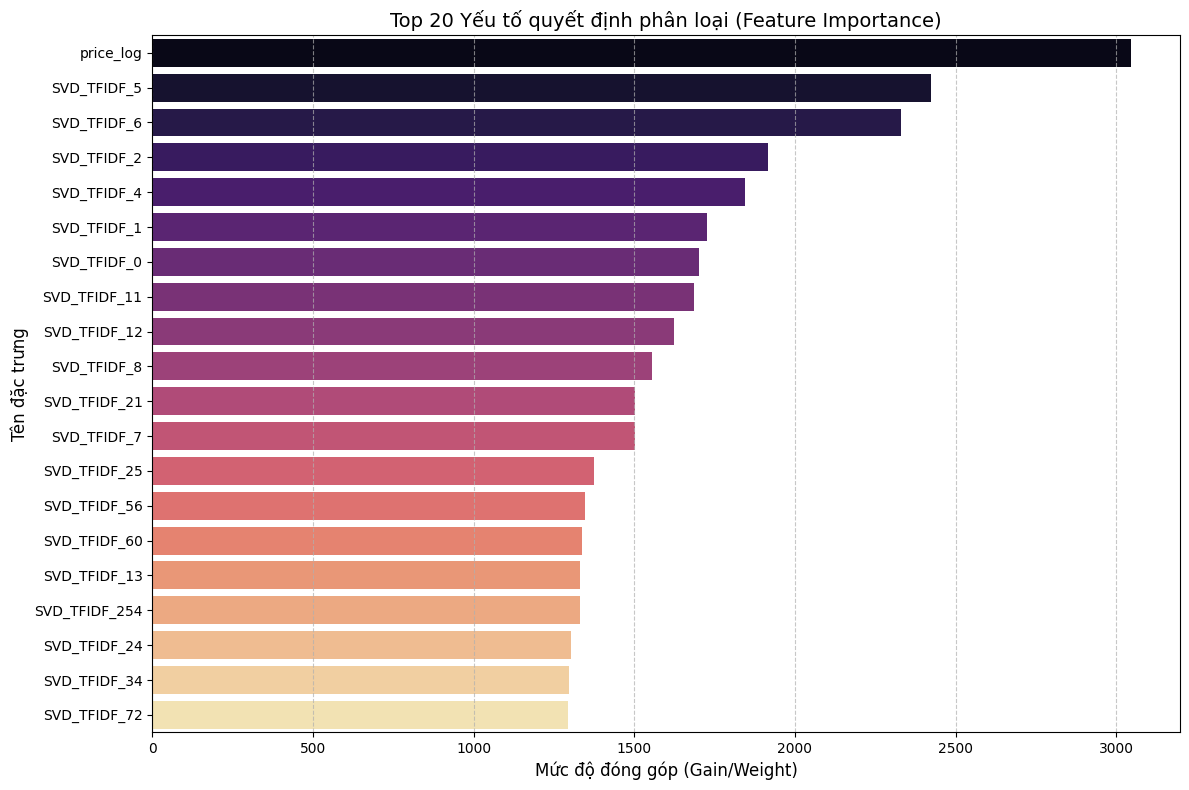

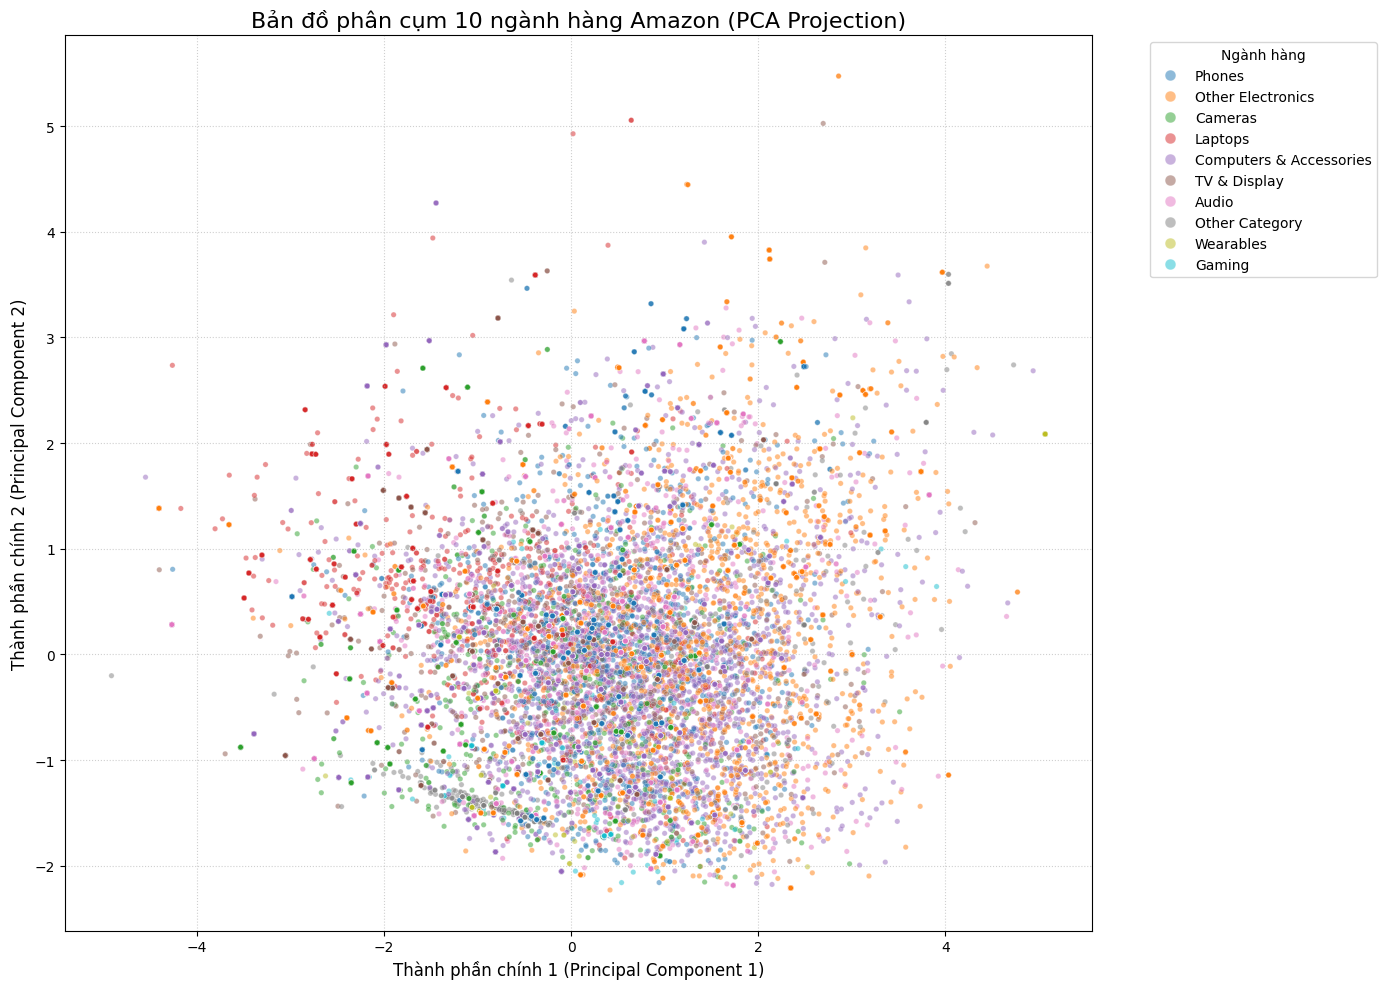

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
# tap train
if 'engine' in globals() and hasattr(engine.model, 'feature_importances_'):

    feat_num = engine.numeric_cols
    feat_pca = [f"PCA_Text_{i}" for i in range(engine.pca.n_components_)]
    feat_svd = [f"SVD_TFIDF_{i}" for i in range(engine.svd.n_components)]
    all_features = feat_num + feat_pca + feat_svd
    # Tạo DataFrame để lưu tên đặc trưng và mức độ quan trọng tương ứng
    imp_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': engine.model.feature_importances_
    })

    top_20 = imp_df.sort_values(by='Importance', ascending=False).head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=top_20, palette='magma')
    plt.title('Top 20 Yếu tố quyết định phân loại (Feature Importance)', fontsize=14)
    plt.xlabel('Mức độ đóng góp (Gain/Weight)', fontsize=12)
    plt.ylabel('Tên đặc trưng', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if 'X_dense_all' in globals() and 'y' in globals():

    pca_plot = PCA(n_components=2, random_state=42)
    X_reduced = pca_plot.fit_transform(X_dense_all)

    plt.figure(figsize=(14, 10))
    label_names = engine.le.inverse_transform(y)

    scatter = sns.scatterplot(
        x=X_reduced[:, 0], y=X_reduced[:, 1],
        hue=label_names,
        palette='tab10',
        alpha=0.5,
        s=15
    )
#all
    plt.title('Bản đồ phân cụm 10 ngành hàng Amazon (PCA Projection)', fontsize=16)
    plt.legend(title='Ngành hàng', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
    plt.xlabel('Thành phần chính 1 (Principal Component 1)', fontsize=12)
    plt.ylabel('Thành phần chính 2 (Principal Component 2)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy X_dense_all hoặc y trong RAM để vẽ bản đồ.")

Training until validation scores don't improve for 50 rounds
[100]	Train's multi_logloss: 0.30697	Validation's multi_logloss: 0.404139
[200]	Train's multi_logloss: 0.08302	Validation's multi_logloss: 0.197106
[300]	Train's multi_logloss: 0.0287654	Validation's multi_logloss: 0.150967
[400]	Train's multi_logloss: 0.0124191	Validation's multi_logloss: 0.138149
[500]	Train's multi_logloss: 0.00660086	Validation's multi_logloss: 0.134831
[600]	Train's multi_logloss: 0.00416073	Validation's multi_logloss: 0.134393
Early stopping, best iteration is:
[581]	Train's multi_logloss: 0.00449141	Validation's multi_logloss: 0.134352


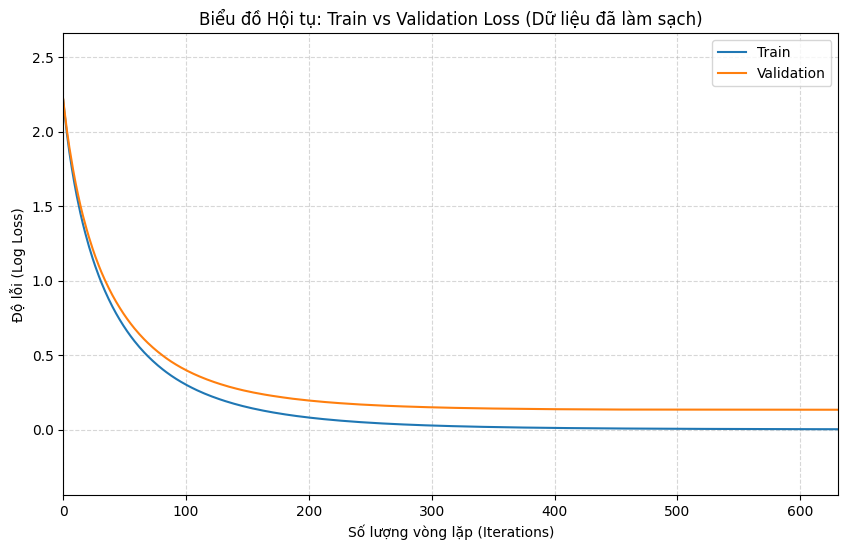

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
#test
final_params = study.best_params
final_params['objective'] = 'multiclass'
final_params['metric'] = 'multi_logloss'
final_params['class_weight'] = 'balanced'

check_model = lgb.LGBMClassifier(**final_params, n_estimators=1000)

check_model.fit(
    X_train_optuna, y_train_optuna,
    eval_set=[(X_train_optuna, y_train_optuna), (X_test, y_test)],
    eval_names=['Train', 'Validation'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

plt.figure(figsize=(10, 6))
lgb.plot_metric(check_model, metric='multi_logloss', ax=plt.gca())
plt.title('Biểu đồ Hội tụ: Train vs Validation Loss (Dữ liệu đã làm sạch)')
plt.xlabel('Số lượng vòng lặp (Iterations)')
plt.ylabel('Độ lỗi (Log Loss)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()